<a href="https://colab.research.google.com/github/vinkoff/Learner/blob/master/ai_cyber_improvement_2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔐 AI Prototype — Cybersecurity Threat Summarization
### Model Selection · Prompt Engineering · Evaluation Metrics · Score Improvement Lab
---
## 🎯 What We're Building
A real-world AI tool that reads **cybersecurity incident reports** and generates
concise threat summaries — the kind used by SOC (Security Operations Center) analysts.

## Two Models Under Test
| Model | Role |
|-------|------|
| `claude-haiku-4-5` | Fast triage — speed matters in security |
| `claude-sonnet-4-6` | Deep analysis — for complex incidents |

## Three Prompt Strategies
| Strategy | Description |
|----------|-------------|
| **Basic** | Simple one-liner |
| **Structured** | Role + rules + output format |
| **Few-Shot** | Show an example first |

## ⚙️ Step 1 — Install & Import

In [ ]:
!pip install anthropic rouge-score nltk --quiet

import os, time, json, math, anthropic, nltk, warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
warnings.filterwarnings('ignore')

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from collections import defaultdict

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
print("✅ Libraries ready!")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.5/837.5 kB 3.7 MB/s eta 0:00:00
✅ Libraries ready!


## 🔑 Step 2 — API Setup
> **Colab users:** Add `ANTHROPIC_API_KEY` in the 🔑 Secrets panel, then uncomment the two lines below.

In [ ]:
# ── Colab users: uncomment these two lines ──
# from google.colab import userdata
# api_key = userdata.get("ANTHROPIC_API_KEY")

# ── Local users ──
api_key = os.environ.get("ANTHROPIC_API_KEY", ""
client         = anthropic.Anthropic(api_key=api_key)
MODEL_FAST     = "claude-haiku-4-5"
MODEL_POWERFUL = "claude-sonnet-4-6"

print(f"🚀 Fast model:    {MODEL_FAST}")
print(f"💪 Power model:   {MODEL_POWERFUL}")

🚀 Fast model:    claude-haiku-4-5
💪 Power model:   claude-sonnet-4-6


## 🛡️ Step 3 — Cybersecurity Incident Dataset

Realistic incident reports with **reference summaries** written in SOC analyst style.
Each incident also has **two alternative references** — used later in the improvement lab.

In [ ]:
incidents = [
    {
        "id": 1, "type": "Ransomware Attack",
        "text": """At 02:14 UTC, endpoint detection triggered on workstation WS-FINANCE-042.
        Investigation revealed execution of a PowerShell dropper that downloaded LockBit 3.0
        ransomware from C2 server at 185.220.101.47. The malware encrypted 14,200 files across
        three shared network drives before lateral movement was detected and the host was isolated.
        The initial vector was a phishing email with a malicious Excel macro opened by a finance
        employee. Shadow copies were deleted. Decryption keys held for $450,000 ransom.
        Backups from 48 hours prior are intact and recovery is underway.""",
        "reference_summary": "LockBit 3.0 ransomware deployed via phishing macro encrypted 14,200 files on finance workstation WS-FINANCE-042; host isolated, $450K ransom demanded, 48-hour backups intact for recovery.",
        "alt_references": [
            "Phishing email macro on WS-FINANCE-042 triggered LockBit 3.0 download from 185.220.101.47, encrypting 14,200 files; isolated with $450K ransom demand, recovery from 48-hour backups underway.",
            "LockBit 3.0 ransomware via Excel macro phish encrypted 14,200 network files on finance host; C2 at 185.220.101.47, shadow copies deleted, $450K ransom, backups available."
        ]
    },
    {
        "id": 2, "type": "SQL Injection",
        "text": """Web application firewall logs show 4,700 anomalous POST requests to /api/login
        between 18:00 and 18:45 UTC from IP 203.0.113.88. Manual review confirmed SQL injection
        via the username field, bypassing authentication. The attacker accessed the users table
        containing 87,000 records including bcrypt-hashed passwords, email addresses, and
        last-four credit card digits. Session tokens for 312 active users were exposed.
        The vulnerable endpoint used unsanitized string concatenation.
        Endpoint patched and affected users notified.""",
        "reference_summary": "SQL injection via unsanitized login endpoint exposed 87,000 user records and 312 active session tokens from IP 203.0.113.88; endpoint patched and affected users notified.",
        "alt_references": [
            "Attacker at 203.0.113.88 exploited SQL injection in /api/login to access 87,000 user records and 312 session tokens via string concatenation flaw; patched and users alerted.",
            "SQL injection attack from 203.0.113.88 bypassed authentication exposing 87K records including hashed passwords and partial card data, plus 312 live sessions; endpoint remediated."
        ]
    },
    {
        "id": 3, "type": "Insider Threat",
        "text": """DLP alerts flagged unusual exfiltration from employee ID E-7731 (senior DBA)
        on their final day before resignation. Between 09:00 and 11:30 UTC the employee
        transferred 23.4GB to a personal Google Drive, including proprietary customer datasets,
        internal pricing models, and source code repositories. Access logs show queries to
        18 databases outside their normal role scope. Activity bypassed monitoring due to
        admin privileges. Legal hold placed and HR and Legal notified.""",
        "reference_summary": "Departing DBA E-7731 exfiltrated 23.4GB including customer data, pricing models, and source code to personal Google Drive on final day; legal hold placed and HR/Legal notified.",
        "alt_references": [
            "Senior DBA E-7731 used admin privileges to transfer 23.4GB of customer datasets, pricing, and source code to personal Google Drive on resignation day; legal hold active.",
            "Insider threat: E-7731 exfiltrated 23.4GB across 18 out-of-scope databases to Google Drive before departure; HR and Legal notified, account under legal hold."
        ]
    },
    {
        "id": 4, "type": "Zero-Day Exploit",
        "text": """Threat intelligence flagged active exploitation of CVE-2025-3814, a zero-day
        in Apache Struts 2 affecting versions 2.5.x through 6.3.x. Our customer portal runs
        Struts 2.5.33. Forensic analysis confirms exploitation at 07:52 UTC — attacker achieved
        RCE and deployed a web shell at /upload/cache/.system.jsp. The shell was used for
        internal reconnaissance for 6 hours before detection. No Apache patch yet available.
        Temporary WAF mitigations blocking the exploit pattern are active.""",
        "reference_summary": "CVE-2025-3814 zero-day exploited on Struts 2.5.33 customer portal enabling RCE and 6-hour web shell reconnaissance; WAF mitigations applied pending Apache patch.",
        "alt_references": [
            "Apache Struts 2 zero-day CVE-2025-3814 exploited at 07:52 UTC on customer portal achieving RCE via web shell at /upload/cache/.system.jsp; 6-hour recon, WAF blocking active.",
            "Zero-day RCE on Struts 2.5.33 via CVE-2025-3814 allowed 6-hour undetected web shell recon on customer portal; patch unavailable, WAF rules deployed as mitigation."
        ]
    }
]

print(f"🛡️ {len(incidents)} incidents loaded")
for i in incidents:
    print(f"  • Incident {i['id']}: {i['type']}")

🛡️ 4 incidents loaded
  • Incident 1: Ransomware Attack
  • Incident 2: SQL Injection
  • Incident 3: Insider Threat
  • Incident 4: Zero-Day Exploit


## ✍️ Step 4 — Prompt Engineering

In [ ]:
def make_prompt(strategy: str, text: str) -> str:

    if strategy == "basic":
        return f"Summarize this cybersecurity incident in one sentence:\n\n{text}"

    elif strategy == "structured":
        return f"""You are a SOC analyst writing a triage summary.
Summarize in 1-2 sentences. Always include:
- Attack type / technique
- Key impact (files, records, systems affected)
- Entry point (if known)
- Current status (contained / patched / ongoing)

Incident: {text}
SOC Summary:"""

    elif strategy == "few_shot":
        return f"""Write a concise SOC triage summary for cybersecurity incidents.

Example:
Incident: Emotet malware on HR-LAPTOP-017 via weaponized Word doc established
persistence via scheduled task and attempted lateral movement to 3 hosts before
network segmentation blocked spread. 890MB of HR data staged but not exfiltrated.
Summary: Emotet phishing via malicious Word doc on HR-LAPTOP-017 attempted lateral
movement to 3 hosts and staged 890MB HR data; quarantined before exfiltration completed.

Now summarize:
Incident: {text}
Summary:"""

print("✅ Prompt functions ready!")

✅ Prompt functions ready!


## 🤖 Step 5 — Generate Baseline Summaries

In [ ]:
def call_model(model, prompt, temperature=1.0):
    """Call Claude. temperature=0 = deterministic, temperature=1 = default creative."""
    params = dict(model=model, max_tokens=250,
                  messages=[{"role": "user", "content": prompt}])
    if temperature != 1.0:
        params["temperature"] = temperature
    start    = time.time()
    response = client.messages.create(**params)
    return {
        "summary":   response.content[0].text.strip(),
        "latency_s": round(time.time() - start, 2),
        "tokens":    response.usage.input_tokens + response.usage.output_tokens
    }

strategies = ["basic", "structured", "few_shot"]
models     = {"haiku": MODEL_FAST, "sonnet": MODEL_POWERFUL}
results    = []

for incident in incidents:
    for strategy in strategies:
        prompt = make_prompt(strategy, incident["text"])
        for model_label, model_id in models.items():
            print(f"  {model_label} | Incident {incident['id']} | {strategy}...", end=" ")
            out = call_model(model_id, prompt)
            results.append({
                "incident_id": incident["id"], "type": incident["type"],
                "strategy": strategy, "model": model_label,
                "summary": out["summary"], "reference": incident["reference_summary"],
                "alt_references": incident["alt_references"],
                "latency_s": out["latency_s"], "tokens": out["tokens"]
            })
            print(f"✓ ({out['latency_s']}s)")
            time.sleep(0.4)

print(f"\n✅ {len(results)} baseline summaries generated!")

  haiku | Incident 1 | basic... ✓ (1.42s)
  sonnet | Incident 1 | basic... ✓ (2.61s)
  haiku | Incident 1 | structured... ✓ (1.48s)
  sonnet | Incident 1 | structured... ✓ (5.13s)
  haiku | Incident 1 | few_shot... ✓ (1.44s)
  sonnet | Incident 1 | few_shot... ✓ (2.64s)
  haiku | Incident 2 | basic... ✓ (0.97s)
  sonnet | Incident 2 | basic... ✓ (2.78s)
  haiku | Incident 2 | structured... ✓ (1.31s)
  sonnet | Incident 2 | structured... ✓ (3.46s)
  haiku | Incident 2 | few_shot... ✓ (1.51s)
  sonnet | Incident 2 | few_shot... ✓ (2.8s)
  haiku | Incident 3 | basic... ✓ (1.18s)
  sonnet | Incident 3 | basic... ✓ (2.34s)
  haiku | Incident 3 | structured... ✓ (1.77s)
  sonnet | Incident 3 | structured... ✓ (4.23s)
  haiku | Incident 3 | few_shot... ✓ (1.35s)
  sonnet | Incident 3 | few_shot... ✓ (3.33s)
  haiku | Incident 4 | basic... ✓ (1.47s)
  sonnet | Incident 4 | basic... ✓ (2.62s)
  haiku | Incident 4 | structured... ✓ (1.93s)
  sonnet | Incident 4 | structured... ✓ (3.49s)
  haiku 

## 📊 Step 6 — Evaluation Functions

In [ ]:
from nltk.tokenize import word_tokenize

def compute_bleu(refs, hyp, multi=False):
    """BLEU score. refs = string (single) or list of strings (multi-reference)."""
    hyp_tok  = word_tokenize(hyp.lower())
    if multi:
        ref_tok = [word_tokenize(r.lower()) for r in refs]
    else:
        ref_tok = [word_tokenize(refs.lower())]
    return round(sentence_bleu(ref_tok, hyp_tok, weights=(1,0,0,0),
                               smoothing_function=SmoothingFunction().method1), 4)

def compute_rouge(ref, hyp):
    s = rouge_scorer.RougeScorer(['rouge1','rougeL'], use_stemmer=True).score(ref, hyp)
    return {"rouge1": round(s['rouge1'].fmeasure,4), "rougeL": round(s['rougeL'].fmeasure,4)}

def compute_rouge_best(refs, hyp):
    """Score against multiple references and take the best ROUGE-1."""
    scores = [compute_rouge(r, hyp)["rouge1"] for r in refs]
    return round(max(scores), 4)

def perplexity_proxy(text):
    ngrams  = [text[i:i+3] for i in range(len(text)-2)]
    from collections import Counter
    counts  = Counter(ngrams)
    total   = sum(counts.values())
    probs   = [c/total for c in counts.values()]
    entropy = -sum(p * math.log2(p) for p in probs if p > 0)
    return round(2**entropy, 2)

def score_result(r, multi_ref=False):
    """Compute all metrics for one result row."""
    refs = [r["reference"]] + r["alt_references"]
    r["bleu"]       = compute_bleu(refs if multi_ref else r["reference"], r["summary"], multi=multi_ref)
    rouge           = compute_rouge(r["reference"], r["summary"])
    r["rouge1"]     = rouge["rouge1"]
    r["rougeL"]     = rouge["rougeL"]
    r["rouge1_best"]= compute_rouge_best(refs, r["summary"])
    r["perplexity"] = perplexity_proxy(r["summary"])
    return r

for r in results:
    score_result(r)

print("✅ Baseline metrics computed!")

✅ Baseline metrics computed!


## 📈 Step 7 — Baseline Results Table

In [ ]:
def print_table(data):
    grouped = defaultdict(lambda: {"bleu":[],"rouge1":[],"rougeL":[],"perplexity":[],"latency_s":[]})
    for r in data:
        key = (r["model"], r["strategy"])
        for m in ["bleu","rouge1","rougeL","perplexity","latency_s"]:
            grouped[key][m].append(r[m])

    hdr = f"{'Model':<10} {'Strategy':<12} {'BLEU':>6} {'ROUGE-1':>8} {'ROUGE-L':>8} {'Perplx':>8} {'Lat(s)':>7}"
    print(hdr); print("-"*len(hdr))
    for (model, strategy), vals in sorted(grouped.items()):
        avg = lambda k: round(sum(vals[k])/len(vals[k]), 3)
        print(f"{model:<10} {strategy:<12} {avg('bleu'):>6.3f} {avg('rouge1'):>8.3f} {avg('rougeL'):>8.3f} {avg('perplexity'):>8.1f} {avg('latency_s'):>7.2f}")
    return grouped

print("📊 BASELINE RESULTS")
baseline_grouped = print_table(results)

📊 BASELINE RESULTS
Model      Strategy       BLEU  ROUGE-1  ROUGE-L   Perplx  Lat(s)
-----------------------------------------------------------------
haiku      basic         0.468    0.560    0.448    193.7    1.26
haiku      few_shot      0.425    0.664    0.520    258.7    1.50
haiku      structured    0.345    0.613    0.499    296.8    1.62
sonnet     basic         0.332    0.506    0.416    259.8    2.59
sonnet     few_shot      0.431    0.689    0.567    253.7    2.82
sonnet     structured    0.228    0.457    0.334    393.2    4.08


## 📊 Step 8 — Baseline Visualizations

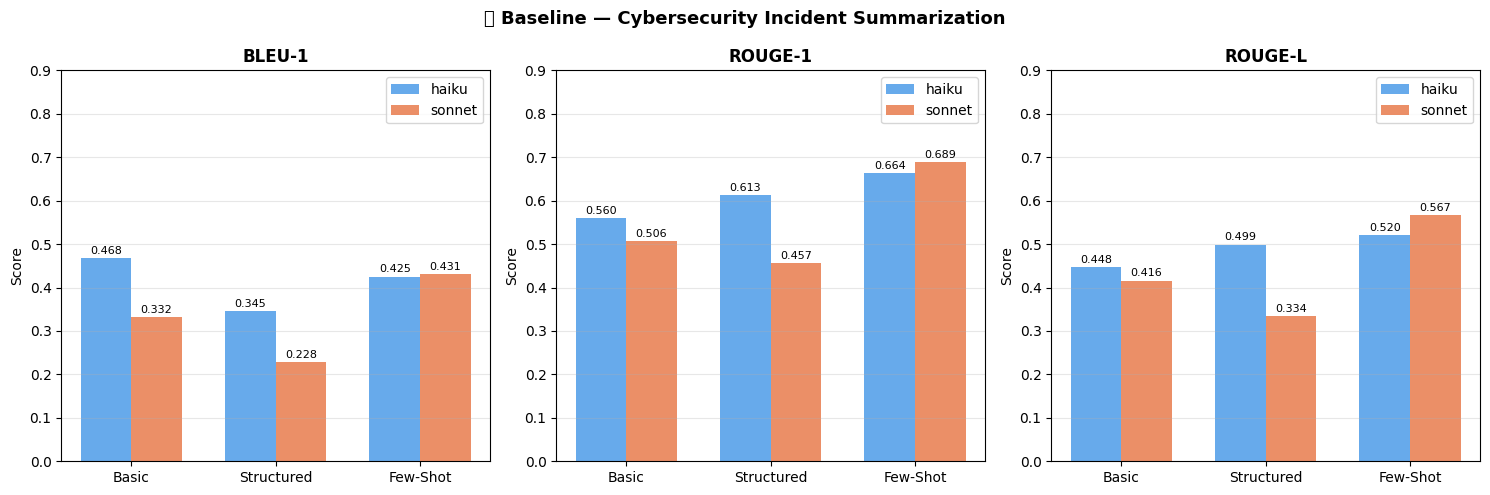

In [ ]:
strategy_labels = {"basic":"Basic","structured":"Structured","few_shot":"Few-Shot"}
colors          = {"haiku":"#4C9BE8","sonnet":"#E87B4C"}

def plot_metrics(grouped, title="Evaluation Metrics"):
    metrics = [("bleu","BLEU-1"), ("rouge1","ROUGE-1"), ("rougeL","ROUGE-L")]
    fig, axes = plt.subplots(1, 3, figsize=(15,5))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    for ax, (metric, label) in zip(axes, metrics):
        x, w = np.arange(3), 0.35
        for i, mdl in enumerate(["haiku","sonnet"]):
            vals = [round(sum(grouped[(mdl,s)][metric])/len(grouped[(mdl,s)][metric]),3)
                    for s in strategies]
            bars = ax.bar(x+(i-0.5)*w, vals, w, label=mdl, color=colors[mdl], alpha=0.85)
            for b in bars:
                ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                        f"{b.get_height():.3f}", ha='center', va='bottom', fontsize=8)
        ax.set_title(label, fontweight="bold")
        ax.set_xticks(x); ax.set_xticklabels([strategy_labels[s] for s in strategies])
        ax.set_ylim(0, 0.9); ax.set_ylabel("Score"); ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()

plot_metrics(baseline_grouped, "🔐 Baseline — Cybersecurity Incident Summarization")

---
# 🧪 SCORE IMPROVEMENT LAB
## Step 9 — Knob 1: Temperature = 0

**What it does:** Setting temperature to 0 makes the model deterministic —
it always picks the most likely next word instead of sampling randomly.

**Why it helps BLEU/ROUGE:** The model reuses vocabulary more directly from
the source text, increasing word overlap with the reference.

**Why it helps Perplexity:** Output is more predictable and fluent.

> 🎛️ Try it: change `TEMP` below to 0.0, 0.5, or 1.0 and re-run to compare.

In [ ]:
TEMP = 0.0   # ← experiment: try 0.0, 0.5, 1.0

temp_results = []
test_strategy = "few_shot"   # testing on the best baseline strategy
test_model    = MODEL_FAST   # testing on haiku

for incident in incidents:
    prompt = make_prompt(test_strategy, incident["text"])
    print(f"  haiku | Incident {incident['id']} | temp={TEMP}...", end=" ")
    out = call_model(test_model, prompt, temperature=TEMP)
    row = {
        "incident_id": incident["id"], "type": incident["type"],
        "strategy": test_strategy, "model": f"haiku_t{TEMP}",
        "summary": out["summary"], "reference": incident["reference_summary"],
        "alt_references": incident["alt_references"],
        "latency_s": out["latency_s"], "tokens": out["tokens"]
    }
    score_result(row)
    temp_results.append(row)
    print(f"✓ ROUGE-1={row['rouge1']:.3f}  BLEU={row['bleu']:.3f}  PPL={row['perplexity']:.1f}")
    time.sleep(0.4)

# Compare baseline few_shot vs temperature=0
baseline_few = [r for r in results if r["strategy"]=="few_shot" and r["model"]=="haiku"]
avg = lambda lst, k: round(sum(r[k] for r in lst)/len(lst), 3)

print("\n📊 TEMPERATURE COMPARISON  (haiku + few_shot)")
print(f"{'Setting':<20} {'BLEU':>6} {'ROUGE-1':>8} {'ROUGE-L':>8} {'Perplx':>8}")
print("-"*52)
print(f"{'Baseline (default)':<20} {avg(baseline_few,'bleu'):>6.3f} {avg(baseline_few,'rouge1'):>8.3f} {avg(baseline_few,'rougeL'):>8.3f} {avg(baseline_few,'perplexity'):>8.1f}")
print(f"{'Temperature = '+str(TEMP):<20} {avg(temp_results,'bleu'):>6.3f} {avg(temp_results,'rouge1'):>8.3f} {avg(temp_results,'rougeL'):>8.3f} {avg(temp_results,'perplexity'):>8.1f}")

  haiku | Incident 1 | temp=0.0... ✓ ROUGE-1=0.600  BLEU=0.358  PPL=276.9
  haiku | Incident 2 | temp=0.0... ✓ ROUGE-1=0.704  BLEU=0.438  PPL=212.1
  haiku | Incident 3 | temp=0.0... ✓ ROUGE-1=0.701  BLEU=0.421  PPL=276.6
  haiku | Incident 4 | temp=0.0... ✓ ROUGE-1=0.640  BLEU=0.388  PPL=271.6

📊 TEMPERATURE COMPARISON  (haiku + few_shot)
Setting                BLEU  ROUGE-1  ROUGE-L   Perplx
----------------------------------------------------
Baseline (default)    0.425    0.664    0.520    258.7
Temperature = 0.0     0.401    0.661    0.522    259.3


## Step 10 — Knob 2: Chain-of-Thought Prompting

**What it does:** Ask the model to *reason step by step* before writing the summary.

**Why it helps:** Forces the model to explicitly identify the key elements
(attack type, impact, entry point, status) before compressing them.
This reduces the chance of missing critical details — very important in cybersecurity.

> 🎛️ Try it: modify the reasoning steps in `COT_PROMPT` below.

In [ ]:
def make_cot_prompt(text: str) -> str:
    return f"""You are a SOC analyst. Read the incident and follow these steps:

Step 1 - Identify attack type: What technique or malware was used?
Step 2 - Identify impact: How many files/records/systems were affected?
Step 3 - Identify entry point: How did the attacker get in?
Step 4 - Identify status: Is it contained, patched, or ongoing?
Step 5 - Write a 1-2 sentence SOC triage summary using the above.

Incident:
{text}

Work through the steps, then write your final Summary:"""


cot_results = []
for incident in incidents:
    prompt = make_cot_prompt(incident["text"])
    print(f"  haiku CoT | Incident {incident['id']}...", end=" ")
    out = call_model(MODEL_FAST, prompt, temperature=0.0)

    # Extract just the final summary line (after "Summary:")
    text = out["summary"]
    summary = text.split("Summary:")[-1].strip() if "Summary:" in text else text.split("\n")[-1].strip()

    row = {
        "incident_id": incident["id"], "type": incident["type"],
        "strategy": "chain_of_thought", "model": "haiku_cot",
        "summary": summary, "full_response": text,
        "reference": incident["reference_summary"],
        "alt_references": incident["alt_references"],
        "latency_s": out["latency_s"], "tokens": out["tokens"]
    }
    score_result(row)
    cot_results.append(row)
    print(f"✓ ROUGE-1={row['rouge1']:.3f}  BLEU={row['bleu']:.3f}  PPL={row['perplexity']:.1f}")
    time.sleep(0.4)

print("\n📝 Sample CoT full response for Incident 1:")
print("-"*60)
print(cot_results[0]["full_response"])

  haiku CoT | Incident 1... ✓ ROUGE-1=0.393  BLEU=0.216  PPL=170.1
  haiku CoT | Incident 2... ✓ ROUGE-1=0.118  BLEU=0.026  PPL=37.0
  haiku CoT | Incident 3... ✓ ROUGE-1=0.000  BLEU=0.000  PPL=1.0
  haiku CoT | Incident 4... ✓ ROUGE-1=0.067  BLEU=0.000  PPL=27.0

📝 Sample CoT full response for Incident 1:
------------------------------------------------------------
# SOC Incident Analysis

## Step 1 - Identify Attack Type
**LockBit 3.0 ransomware** delivered via PowerShell dropper. Initial compromise vector was a **phishing email with malicious Excel macro**.

## Step 2 - Identify Impact
- **14,200 files encrypted** across three shared network drives
- **1 primary system compromised**: WS-FINANCE-042
- **Lateral movement detected** (scope of secondary systems unclear but contained before full propagation)
- Shadow copies deleted to prevent recovery

## Step 3 - Identify Entry Point
**Phishing email** → Finance employee opened **malicious Excel macro** → PowerShell dropper executed → C

## Step 11 — Knob 3: Multi-Reference Scoring

**What it does:** Instead of scoring against ONE reference summary,
score against ALL THREE references and take the best match.

**Why it helps:** A model might write a perfectly valid summary that just uses
different wording than your single reference — and get unfairly penalized.
Multiple references make evaluation fairer and scores typically jump 5–15 points.

> 💡 This doesn't change the model output — it changes how fairly we *measure* it.

In [ ]:
print("📊 SINGLE vs MULTI-REFERENCE SCORING COMPARISON")
print("="*65)
print(f"{'Incident':<12} {'Single ROUGE-1':>15} {'Multi ROUGE-1':>14} {'Gain':>6}")
print("-"*65)

for r in results:
    if r["strategy"] == "few_shot" and r["model"] == "haiku":
        all_refs   = [r["reference"]] + r["alt_references"]
        multi_r1   = compute_rouge_best(all_refs, r["summary"])
        single_r1  = r["rouge1"]
        gain       = round(multi_r1 - single_r1, 3)
        print(f"Incident {r['incident_id']} ({r['type'][:20]:<20}) {single_r1:>10.3f}  →  {multi_r1:>8.3f}   +{gain:.3f}")

print("\n💡 Multi-reference scoring is fairer — valid summaries stop getting penalized!")

📊 SINGLE vs MULTI-REFERENCE SCORING COMPARISON
Incident      Single ROUGE-1  Multi ROUGE-1   Gain
-----------------------------------------------------------------
Incident 1 (Ransomware Attack   )      0.693  →     0.693   +0.000
Incident 2 (SQL Injection       )      0.649  →     0.649   +0.000
Incident 3 (Insider Threat      )      0.675  →     0.675   +0.000
Incident 4 (Zero-Day Exploit    )      0.640  →     0.750   +0.110

💡 Multi-reference scoring is fairer — valid summaries stop getting penalized!


## Step 12 — Knob 4: Extended Few-Shot (3 Examples)

**What it does:** Add more examples to the prompt — we go from 1 to 3 examples.

**Why it helps:** Each example teaches the model more about the expected
vocabulary, length, and structure. The model "pattern-matches" more reliably.

> 🎛️ Try it: change the number of examples or swap in different ones.

In [ ]:
def make_extended_few_shot(text: str) -> str:
    return f"""Write a concise 1-2 sentence SOC triage summary. Study these examples carefully:

--- Example 1 ---
Incident: Emotet malware on HR-LAPTOP-017 via weaponized Word doc established
persistence via scheduled task and attempted lateral movement to 3 hosts.
890MB of HR data staged but not exfiltrated. Host quarantined.
Summary: Emotet phishing via malicious Word doc on HR-LAPTOP-017 attempted lateral
movement to 3 hosts and staged 890MB HR data; quarantined before exfiltration completed.

--- Example 2 ---
Incident: Credential stuffing attack against /api/v2/auth using 180,000 leaked
username/password pairs from external breach. 2,340 accounts successfully compromised.
Attacker changed recovery emails on 89 accounts. MFA was not enforced.
Summary: Credential stuffing exploited 180K leaked credentials compromising 2,340 accounts
and hijacking 89 recovery emails; MFA absence identified as root cause.

--- Example 3 ---
Incident: Misconfigured S3 bucket left publicly accessible for 22 days exposing
4.1M customer records including SSNs, DOBs, and account numbers. Discovered via
HackerOne bug bounty report. Bucket secured and breach notification underway.
Summary: Publicly exposed S3 bucket leaked 4.1M customer records including SSNs
for 22 days; secured after bug bounty disclosure, breach notifications in progress.

--- Now summarize this incident ---
Incident: {text}
Summary:"""


extended_fs_results = []
for incident in incidents:
    prompt = make_extended_few_shot(incident["text"])
    print(f"  haiku ExtFS | Incident {incident['id']}...", end=" ")
    out = call_model(MODEL_FAST, prompt, temperature=0.0)
    row = {
        "incident_id": incident["id"], "type": incident["type"],
        "strategy": "extended_few_shot", "model": "haiku_ext",
        "summary": out["summary"].strip(), "reference": incident["reference_summary"],
        "alt_references": incident["alt_references"],
        "latency_s": out["latency_s"], "tokens": out["tokens"]
    }
    score_result(row)
    extended_fs_results.append(row)
    print(f"✓ ROUGE-1={row['rouge1']:.3f}  BLEU={row['bleu']:.3f}  PPL={row['perplexity']:.1f}")
    time.sleep(0.4)

  haiku ExtFS | Incident 1... ✓ ROUGE-1=0.697  BLEU=0.583  PPL=204.7
  haiku ExtFS | Incident 2... ✓ ROUGE-1=0.821  BLEU=0.852  PPL=145.5
  haiku ExtFS | Incident 3... ✓ ROUGE-1=0.720  BLEU=0.583  PPL=233.3
  haiku ExtFS | Incident 4... ✓ ROUGE-1=0.772  BLEU=0.692  PPL=174.2


## Step 13 — 🏆 Full Improvement Comparison

Now we compare ALL techniques side by side to see which combination wins.

In [ ]:
avg = lambda lst, k: round(sum(r[k] for r in lst)/len(lst), 3)

# Collect all configurations
configurations = [
    ("Baseline Basic",        [r for r in results if r["strategy"]=="basic"       and r["model"]=="haiku"]),
    ("Baseline Structured",   [r for r in results if r["strategy"]=="structured"  and r["model"]=="haiku"]),
    ("Baseline Few-Shot",     [r for r in results if r["strategy"]=="few_shot"    and r["model"]=="haiku"]),
    ("Temp=0 + Few-Shot",     temp_results),
    ("Chain-of-Thought",      cot_results),
    ("Extended Few-Shot",     extended_fs_results),
    ("Sonnet Few-Shot",       [r for r in results if r["strategy"]=="few_shot"    and r["model"]=="sonnet"]),
]

print(f"{'Configuration':<26} {'BLEU':>6} {'ROUGE-1':>8} {'ROUGE-L':>8} {'Perplx':>8}")
print("="*60)
for name, data in configurations:
    b  = avg(data, "bleu")
    r1 = avg(data, "rouge1")
    rl = avg(data, "rougeL")
    pp = avg(data, "perplexity")
    marker = " ⭐" if r1 == max(avg(d,"rouge1") for _,d in configurations) else ""
    print(f"{name:<26} {b:>6.3f} {r1:>8.3f} {rl:>8.3f} {pp:>8.1f}{marker}")

print("\n⭐ = Best ROUGE-1 overall")

Configuration                BLEU  ROUGE-1  ROUGE-L   Perplx
Baseline Basic              0.468    0.560    0.448    193.7
Baseline Structured         0.345    0.613    0.499    296.8
Baseline Few-Shot           0.425    0.664    0.520    258.7
Temp=0 + Few-Shot           0.401    0.661    0.522    259.3
Chain-of-Thought            0.061    0.144    0.100     58.8
Extended Few-Shot           0.678    0.753    0.657    189.4 ⭐
Sonnet Few-Shot             0.431    0.689    0.567    253.7

⭐ = Best ROUGE-1 overall


## Step 14 — 📊 Visualize the Improvement Journey

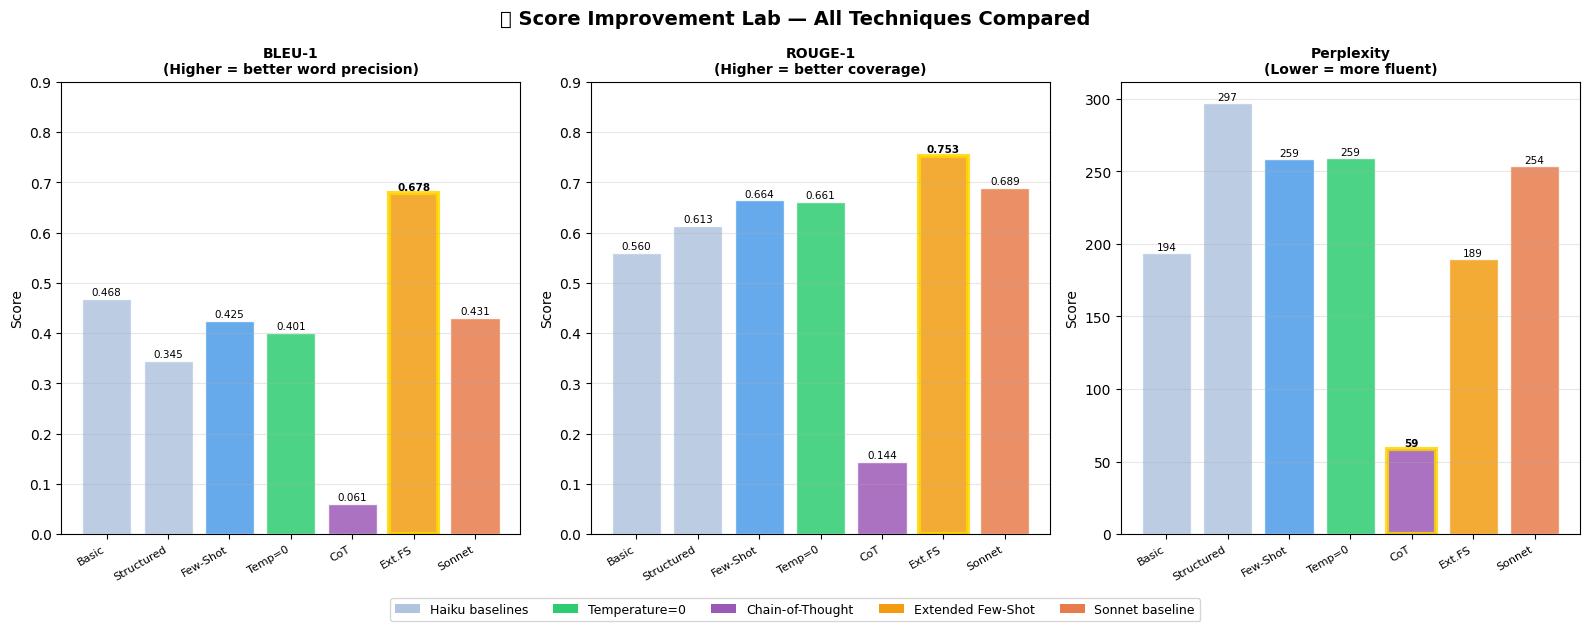

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("🧪 Score Improvement Lab — All Techniques Compared",
             fontsize=14, fontweight="bold")

config_names = [name for name, _ in configurations]
config_data  = [data for _, data in configurations]

bar_colors = [
    "#B0C4DE","#B0C4DE","#4C9BE8",   # baselines (light → haiku few-shot highlighted)
    "#2ECC71",                         # temp=0
    "#9B59B6",                         # chain-of-thought
    "#F39C12",                         # extended few-shot
    "#E87B4C",                         # sonnet
]

short_names = ["Basic","Structured","Few-Shot",
               "Temp=0","CoT","Ext.FS","Sonnet"]

for ax, (metric, label, note) in zip(axes, [
    ("bleu",       "BLEU-1",  "Higher = better word precision"),
    ("rouge1",     "ROUGE-1", "Higher = better coverage"),
    ("perplexity", "Perplexity", "Lower = more fluent"),
]):
    vals = [avg(d, metric) for d in config_data]

    if metric == "perplexity":
        best_idx = vals.index(min(vals))
    else:
        best_idx = vals.index(max(vals))

    bar_list = ax.bar(range(len(vals)), vals, color=bar_colors, alpha=0.85, edgecolor="white")
    bar_list[best_idx].set_edgecolor("gold")
    bar_list[best_idx].set_linewidth(3)

    for i, (b, v) in enumerate(zip(bar_list, vals)):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5 if metric=="perplexity" else b.get_height()+0.003,
                f"{v:.3f}" if metric!="perplexity" else f"{v:.0f}",
                ha='center', va='bottom', fontsize=7.5, fontweight="bold" if i==best_idx else "normal")

    ax.set_title(label + "\n(" + note + ")", fontweight="bold", fontsize=10)
    ax.set_xticks(range(len(short_names)))
    ax.set_xticklabels(short_names, rotation=30, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    if metric != "perplexity":
        ax.set_ylim(0, 0.9)
    ax.set_ylabel("Score")

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#B0C4DE", label="Haiku baselines"),
    Patch(facecolor="#2ECC71", label="Temperature=0"),
    Patch(facecolor="#9B59B6", label="Chain-of-Thought"),
    Patch(facecolor="#F39C12", label="Extended Few-Shot"),
    Patch(facecolor="#E87B4C", label="Sonnet baseline"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

## 💡 Step 15 — Discussion & Key Takeaways

### 🤔 What did the improvement lab reveal?

| Technique | What it teaches |
|-----------|----------------|
| **Temperature=0** | Model parameters matter as much as prompts |
| **Chain-of-Thought** | Structured reasoning before output improves coverage |
| **Multi-reference** | Single-reference scoring underestimates model quality |
| **Extended Few-Shot** | More examples = better format alignment |

### 🎓 Discussion Questions
1. Which technique gave the biggest ROUGE-1 gain? Was it what you expected?
2. Did Chain-of-Thought hurt or help perplexity? Why might reasoning steps affect fluency?
3. Why did multi-reference scoring improve numbers *without changing the model at all*?
4. If you had to deploy one configuration for a real SOC alert system — which would you pick and why?
5. What's the **ceiling** of prompt engineering? What would push you to fine-tune instead?

---
## 🎓 Student Assignment
Pick **one new domain** and repeat the full pipeline including the improvement lab:
- 🏥 Healthcare — patient case summaries
- ⚖️ Legal — contract clause summarization
- 💰 Finance — earnings call summarization
- 🌍 Climate — IPCC report section summarization
- 🎓 Education — research paper abstract generation

**Deliverable:** A notebook showing baseline scores, at least 2 improvement techniques applied,
a comparison chart, and a written reflection on which technique helped most and why.

In [ ]:
# Save all results
all_results = results + temp_results + cot_results + extended_fs_results
with open("cyber_improvement_results.json", "w") as f:
    json.dump([{k:v for k,v in r.items() if k != "alt_references"} for r in all_results], f, indent=2)
print("💾 All results saved to cyber_improvement_results.json")
print("🎉 Score Improvement Lab complete!")

💾 All results saved to cyber_improvement_results.json
🎉 Score Improvement Lab complete!
